<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/visualization/vis_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización de Grafos

## Introducción


<img src="https://networkx.org/_static/networkx_logo.svg" alt="" width="400" align="center"/>

Un **grafo** es una estructura matemática que modela relaciones entre entidades.
En ciencia de datos aparece en redes sociales, rutas de transporte, dependencias de cursos, co-autoría académica, y mucho más.

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns


## Conceptos fundamentales

### Vocabulario básico

| Concepto | Descripción | Ejemplo |
|---|---|---|
| **Nodo** (vertex) | Entidad del grafo | Persona, ciudad, curso |
| **Arista** (edge) | Relación entre dos nodos | Amistad, ruta, prerrequisito |
| **Peso** (weight) | Valor asociado a una arista | Distancia, fuerza de relación |
| **Grado** (degree) | Número de aristas de un nodo | Cuántos amigos tiene alguien |
| **Camino** (path) | Secuencia de nodos conectados | Ruta de A a B |
| **Componente** | Subgrafo conectado | Clúster de usuarios |

### Tipos de grafos

| Tipo | Clase NetworkX | Cuándo usarlo |
|---|---|---|
| No dirigido | `nx.Graph` | Amistades, colaboraciones |
| Dirigido | `nx.DiGraph` | Seguimiento en redes, citaciones |
| Con multi-aristas | `nx.MultiGraph` | Varias relaciones entre el mismo par |
| Bipartito | `nx.Graph` + atributo | Usuarios ↔ productos |


## Crear grafos desde pandas

### Desde una lista de aristas (edge list)

In [2]:
# DataFrame de conexiones
df_edges = pd.DataFrame({
    "source": ["Ana", "Ana", "Luis", "Luis", "María", "Pedro"],
    "target": ["Luis", "María", "María", "Pedro", "Pedro", "Ana"],
    "weight": [3, 5, 2, 4, 1, 6]
})

G = nx.from_pandas_edgelist(
    df_edges,
    source="source",
    target="target",
    edge_attr="weight"
)

print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")

Nodos: 4
Aristas: 6


### Desde una matriz de adyacencia

In [3]:
# Matriz de adyacencia como DataFrame
personas = ["Ana", "Luis", "María", "Pedro"]
matriz = pd.DataFrame([
    [0, 3, 5, 0],
    [3, 0, 2, 4],
    [5, 2, 0, 1],
    [0, 4, 1, 0]
], index=personas, columns=personas)

G_adj = nx.from_pandas_adjacency(matriz)

### Añadir atributos a nodos


In [4]:
# Atributos desde un DataFrame
df_nodos = pd.DataFrame({
    "nombre":     ["Ana", "Luis", "María", "Pedro"],
    "edad":       [28, 35, 31, 24],
    "departamento": ["DS", "Ing", "DS", "Ing"]
})

# Añadir atributos al grafo
for _, row in df_nodos.iterrows():
    G.nodes[row["nombre"]].update(row.to_dict())

# Verificar
print(G.nodes["Ana"])

{'nombre': 'Ana', 'edad': 28, 'departamento': 'DS'}


### Grafo dirigido desde pandas


In [5]:
df_directed = pd.DataFrame({
    "source": ["Ana", "Luis", "María", "Pedro", "Ana"],
    "target": ["Luis", "María", "Pedro", "Ana",  "Pedro"],
    "weight": [1.0, 0.8, 0.5, 0.9, 0.3]
})

DG = nx.from_pandas_edgelist(
    df_directed,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph
)

## Visualización básica

### Plot simple

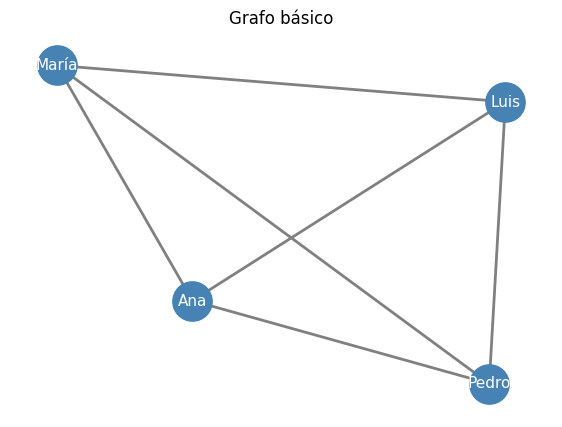

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
nx.draw(G, with_labels=True, node_color="steelblue",
        node_size=800, font_color="white", font_size=11,
        edge_color="grey", width=2, ax=ax)
ax.set_title("Grafo básico")
plt.show()

### Con pesos en las aristas


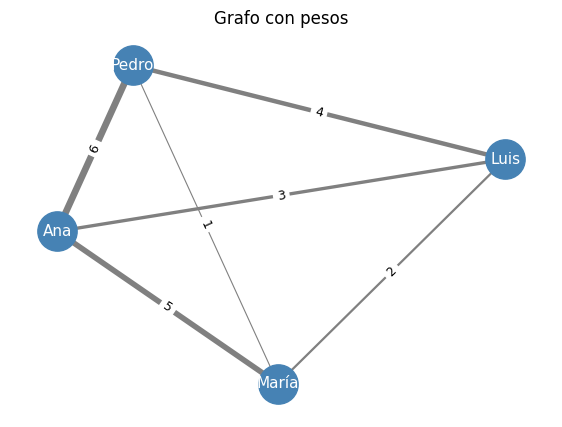

In [7]:
pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]["weight"] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx(G, pos=pos, with_labels=True,
                 node_color="steelblue", node_size=800,
                 font_color="white", font_size=11,
                 edge_color="grey", width=[w * 0.8 for w in weights],
                 ax=ax)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=9, ax=ax)
ax.set_title("Grafo con pesos")
ax.set_axis_off()
plt.show()

##  Layouts (disposición de nodos)
El layout determina dónde se posiciona cada nodo. Elegir bien impacta la legibilidad.

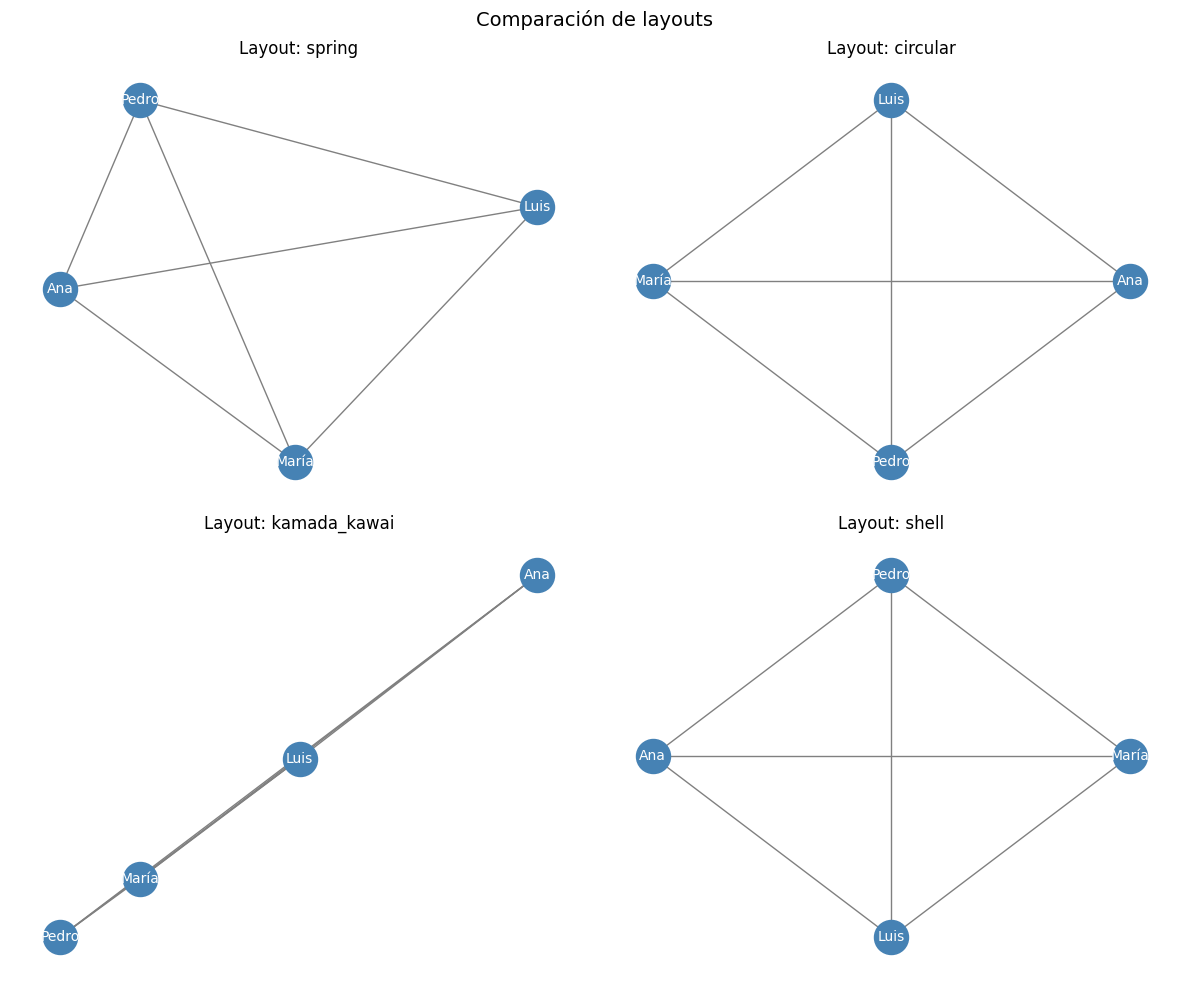

In [8]:
layouts = {
    "spring"    : nx.spring_layout(G, seed=42),
    "circular"  : nx.circular_layout(G),
    "kamada_kawai": nx.kamada_kawai_layout(G),
    "shell"     : nx.shell_layout(G),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (nombre, pos) in zip(axes, layouts.items()):
    nx.draw_networkx(G, pos=pos, ax=ax,
                     node_color="steelblue", node_size=600,
                     font_color="white", font_size=10,
                     edge_color="grey", with_labels=True)
    ax.set_title(f"Layout: {nombre}", fontsize=12)
    ax.set_axis_off()

plt.suptitle("Comparación de layouts", fontsize=14)
plt.tight_layout()
plt.show()


| Layout | Cuándo usarlo |
|---|---|
| `spring` | Grafos generales; separa nodos poco conectados |
| `circular` | Comparar nodos en igualdad de condiciones |
| `kamada_kawai` | Grafos medianos; minimiza cruce de aristas |
| `shell` | Grafos con estructura por capas |
| `spectral` | Grafos grandes; revela estructura de comunidades |
| `planar` | Grafos planares (sin cruces de aristas) |


## Métricas de centralidad
Las métricas de centralidad identifican los nodos más **importantes** según distintos criterios.

In [9]:
# Calcular métricas
grado       = nx.degree_centrality(G)
cercanía    = nx.closeness_centrality(G)
intermediac = nx.betweenness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

# Consolidar en un DataFrame
df_centralidad = pd.DataFrame({
    "degree"      : grado,
    "closeness"   : cercanía,
    "betweenness" : intermediac,
    "eigenvector" : eigenvector
}).round(3)

df_centralidad.sort_values("betweenness", ascending=False)

,degree,closeness,betweenness,eigenvector
Ana,1.0,1.0,0.0,0.5
Luis,1.0,1.0,0.0,0.5
María,1.0,1.0,0.0,0.5
Pedro,1.0,1.0,0.0,0.5


| Métrica | Pregunta que responde |
|---|---|
| **Degree** | ¿Quién tiene más conexiones directas? |
| **Closeness** | ¿Quién llega más rápido a todos los demás? |
| **Betweenness** | ¿Quién actúa como puente entre grupos? |
| **Eigenvector** | ¿Quién está conectado a los más conectados? |
| **PageRank** | ¿Quién recibe más enlaces importantes? (DiGraph) |


### Visualizar centralidad como tamaño de nodo


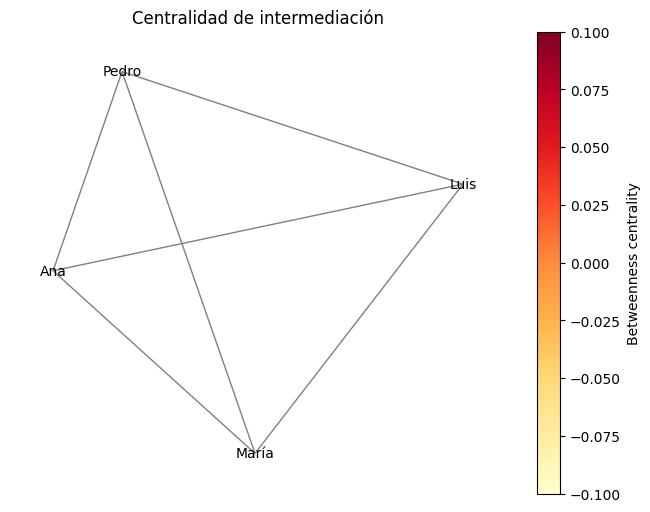

In [11]:
pos = nx.spring_layout(G, seed=42)
tamaños = [v * 5000 for v in intermediac.values()]
colores  = list(intermediac.values())

fig, ax = plt.subplots(figsize=(8, 6))
nc = nx.draw_networkx_nodes(G, pos, node_size=tamaños,
                             node_color=colores, cmap="YlOrRd", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="grey", ax=ax)
nx.draw_networkx_labels(G, pos, font_color="black", font_size=10, ax=ax)
plt.colorbar(nc, ax=ax, label="Betweenness centrality")
ax.set_title("Centralidad de intermediación")
ax.set_axis_off()
plt.show()

## Detección de comunidades
Las comunidades son grupos de nodos más conectados entre sí que con el resto.
### Algoritmo de Louvain

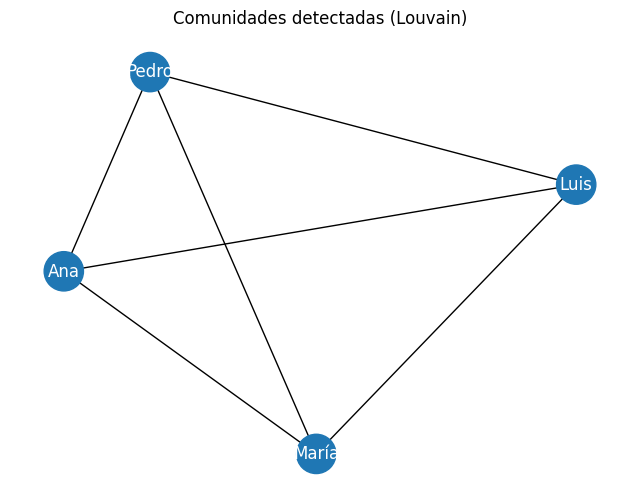

In [12]:
# pip install python-louvain
import community as community_louvain

partition = community_louvain.best_partition(G)
# {nodo: id_comunidad}

# Añadir al grafo como atributo
nx.set_node_attributes(G, partition, "comunidad")

# Visualizar
pos = nx.spring_layout(G, seed=42)
colores = [partition[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(G, pos=pos, node_color=colores,
                 cmap="tab10", node_size=800,
                 font_color="white", with_labels=True, ax=ax)
ax.set_title("Comunidades detectadas (Louvain)")
ax.set_axis_off()
plt.show()

### Girvan-Newman (built-in NetworkX)


In [13]:
from networkx.algorithms.community import girvan_newman

comp = girvan_newman(G)
primera_particion = tuple(sorted(c) for c in next(comp))
print(primera_particion)

(['Ana'], ['Luis', 'María', 'Pedro'])


## Análisis de caminos y componentes


In [14]:
# ¿Están todos los nodos conectados?
print(nx.is_connected(G))

# Componentes conexas
for componente in nx.connected_components(G):
    print(componente)

# Camino más corto
camino = nx.shortest_path(G, source="Ana", target="Pedro", weight="weight")
longitud = nx.shortest_path_length(G, source="Ana", target="Pedro", weight="weight")
print(f"Camino: {camino}  —  longitud: {longitud}")

# Diámetro (camino más largo entre todos los pares)
print(nx.diameter(G))

# Densidad del grafo (0 = sin aristas, 1 = grafo completo)
print(nx.density(G))

True
{'Ana', 'Pedro', 'María', 'Luis'}
Camino: ['Ana', 'Pedro']  —  longitud: 6
1
1.0


### Visualizar el camino más corto


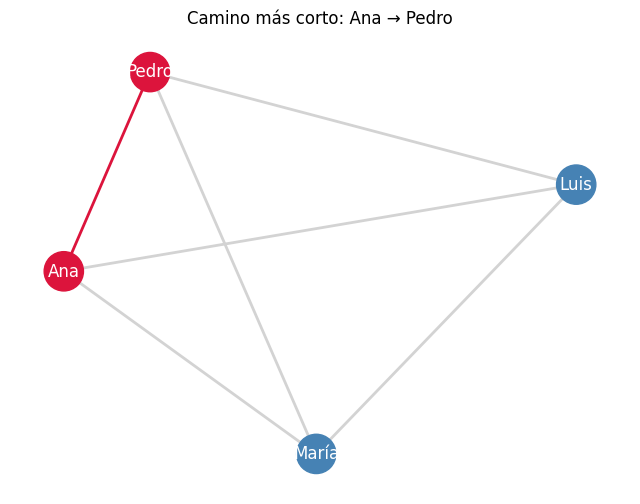

In [15]:
camino_edges = list(zip(camino, camino[1:]))
pos = nx.spring_layout(G, seed=42)

edge_colors = ["crimson" if e in camino_edges or tuple(reversed(e)) in camino_edges
               else "lightgrey" for e in G.edges()]
node_colors = ["crimson" if n in camino else "steelblue" for n in G.nodes()]

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(G, pos=pos, node_color=node_colors,
                 edge_color=edge_colors, node_size=800,
                 font_color="white", with_labels=True,
                 width=2, ax=ax)
ax.set_title(f"Camino más corto: Ana → Pedro")
ax.set_axis_off()
plt.show()

## Grafos dirigidos (DiGraph)


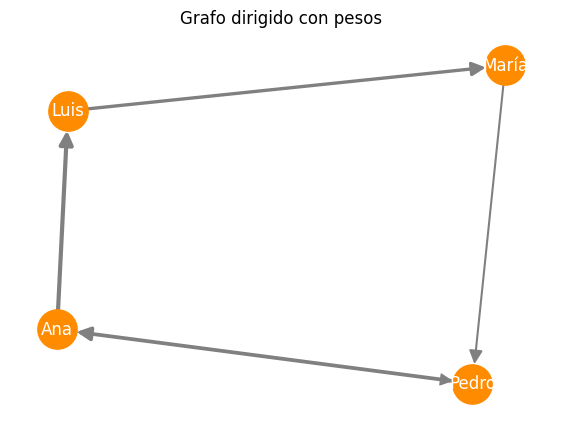

In-degree: {'Ana': 1, 'Luis': 1, 'María': 1, 'Pedro': 2}
Out-degree: {'Ana': 2, 'Luis': 1, 'María': 1, 'Pedro': 1}
PageRank: {'Ana': 0.2767916505532039, 'Luis': 0.21848041111387767, 'María': 0.22320834944679602, 'Pedro': 0.2815195888861223}


In [16]:
pos = nx.spring_layout(DG, seed=42)
weights = [DG[u][v]["weight"] * 3 for u, v in DG.edges()]

fig, ax = plt.subplots(figsize=(7, 5))
nx.draw_networkx(DG, pos=pos, with_labels=True,
                 node_color="darkorange", node_size=800,
                 font_color="white", edge_color="grey",
                 width=weights, arrows=True,
                 arrowsize=20, ax=ax)
ax.set_title("Grafo dirigido con pesos")
ax.set_axis_off()
plt.show()

# Métricas específicas de DiGraph
print("In-degree:",  dict(DG.in_degree()))
print("Out-degree:", dict(DG.out_degree()))
print("PageRank:",   nx.pagerank(DG, weight="weight"))

## Grafo bipartito
**Cuándo:** modelar relaciones entre dos tipos distintos de nodos (usuarios ↔ productos, estudiantes ↔ cursos, autores ↔ artículos).


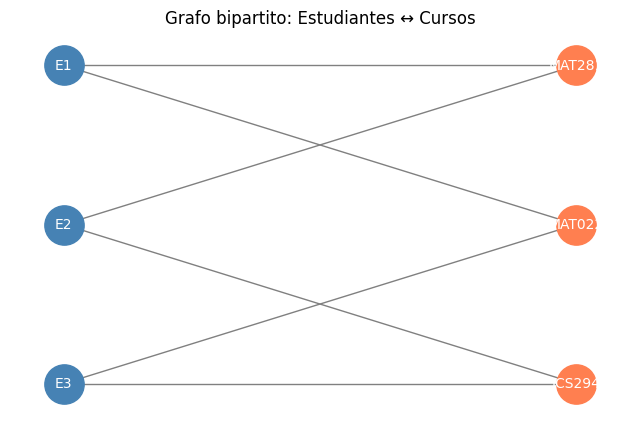

Cursos con estudiantes en común: [('MAT281', 'MAT022'), ('MAT281', 'ICS294'), ('ICS294', 'MAT022')]


In [17]:
from networkx.algorithms import bipartite

B = nx.Graph()

# Capa 0: estudiantes | Capa 1: cursos
estudiantes = ["E1", "E2", "E3"]
cursos      = ["MAT281", "ICS294", "MAT022"]

B.add_nodes_from(estudiantes, bipartite=0)
B.add_nodes_from(cursos,      bipartite=1)

B.add_edges_from([("E1", "MAT281"), ("E1", "MAT022"),
                  ("E2", "MAT281"), ("E2", "ICS294"),
                  ("E3", "ICS294"), ("E3", "MAT022")])

# Layout bipartito
pos = nx.bipartite_layout(B, estudiantes)

fig, ax = plt.subplots(figsize=(8, 5))
nx.draw_networkx_nodes(B, pos, nodelist=estudiantes,
                        node_color="steelblue", node_size=800, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=cursos,
                        node_color="coral", node_size=800, ax=ax)
nx.draw_networkx_edges(B, pos, edge_color="grey", ax=ax)
nx.draw_networkx_labels(B, pos, font_color="white", font_size=10, ax=ax)
ax.set_title("Grafo bipartito: Estudiantes ↔ Cursos")
ax.set_axis_off()
plt.show()

# Proyección: qué cursos comparten estudiantes
proyeccion_cursos = bipartite.projected_graph(B, cursos)
print("Cursos con estudiantes en común:", list(proyeccion_cursos.edges()))

##  Análisis completo desde pandas

### Dataset: red de co-autoría académica


  autor_x autor_y  colaboraciones
0     Ana    Luis               1
1     Ana   María               1
2     Ana   Pedro               1
3    Luis   María               2
4    Luis   Pedro               1
5   María   Pedro               1
       grado  betweenness  pagerank
Ana        3          0.0      0.25
Luis       3          0.0      0.25
María      3          0.0      0.25
Pedro      3          0.0      0.25


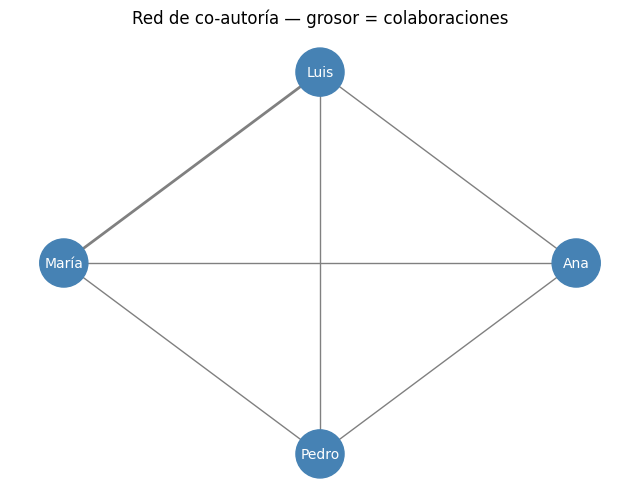

In [23]:
# Simular publicaciones con múltiples autores
publicaciones = pd.DataFrame({
    "paper_id": [1, 1, 1, 2, 2, 3, 3, 3, 4],
    "autor":    ["Ana", "Luis", "María", "Ana", "Pedro",
                 "Luis", "Pedro", "María", "Ana"]
})

# Generar pares de co-autores por paper
pares = (publicaciones
    .merge(publicaciones, on="paper_id")
    .query("autor_x < autor_y")   # evitar duplicados
    .groupby(["autor_x", "autor_y"])
    .size()
    .reset_index(name="colaboraciones"))

print(pares)

# Construir grafo
G_coautoria = nx.from_pandas_edgelist(
    pares,
    source="autor_x",
    target="autor_y",
    edge_attr="colaboraciones"
)

# Métricas
df_metricas = pd.DataFrame({
    "grado"      : dict(G_coautoria.degree()),
    "betweenness": nx.betweenness_centrality(G_coautoria),
    "pagerank"   : nx.pagerank(G_coautoria)
}).round(3).sort_values("betweenness", ascending=False)

print(df_metricas)

# Visualizar
pos = nx.kamada_kawai_layout(G_coautoria)
tamaños = [G_coautoria.degree(n) * 400 for n in G_coautoria.nodes()]
pesos   = [G_coautoria[u][v]["colaboraciones"] for u, v in G_coautoria.edges()]

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(G_coautoria, pos=pos,
                 node_size=tamaños, node_color="steelblue",
                 font_color="white", font_size=10,
                 edge_color="grey", width=pesos,
                 with_labels=True, ax=ax)
ax.set_title("Red de co-autoría — grosor = colaboraciones")
ax.set_axis_off()
plt.show()

## Exportar e importar grafos


In [24]:
# Exportar a DataFrame de aristas
df_export = nx.to_pandas_edgelist(G)

# Guardar como GML, GraphML, JSON
nx.write_gml(G,     "grafo.gml")
nx.write_graphml(G, "grafo.graphml")
from networkx.readwrite import json_graph
import json
data = json_graph.node_link_data(G)
with open("grafo.json", "w") as f:
    json.dump(data, f)

# Cargar
G2 = nx.read_gml("grafo.gml")